FIRST 5 ROWS
   ID City_Code  Region_Code Accomodation_Type Reco_Insurance_Type  Upper_Age  \
0   1        C3         3213            Rented          Individual         36   
1   2        C5         1117             Owned               Joint         75   
2   3        C5         3732             Owned          Individual         32   
3   4       C24         4378             Owned               Joint         52   
4   5        C8         2190            Rented          Individual         44   

   Lower_Age Is_Spouse Health Indicator Holding_Policy_Duration  \
0         36        No               X1                     14+   
1         22        No               X2                     NaN   
2         32        No              NaN                     1.0   
3         48        No               X1                     14+   
4         44        No               X2                     3.0   

   Holding_Policy_Type  Reco_Policy_Cat  Reco_Policy_Premium  Response  
0                  3.0  

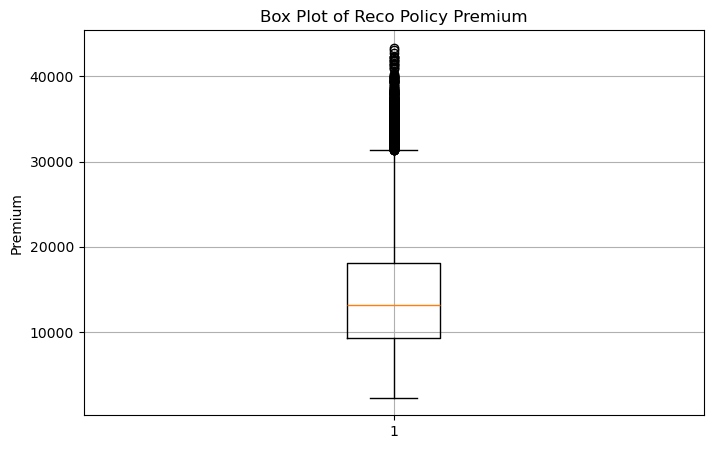


MIN-MAX NORMALIZATION
   Upper_Age  Lower_Age  Holding_Policy_Type  Reco_Policy_Premium
0   0.315789   0.338983             0.666667             0.227609
1   1.000000   0.101695             0.479743             0.687356
2   0.245614   0.271186             0.000000             0.125881
3   0.596491   0.542373             0.666667             0.377401
4   0.456140   0.474576             0.000000             0.197807


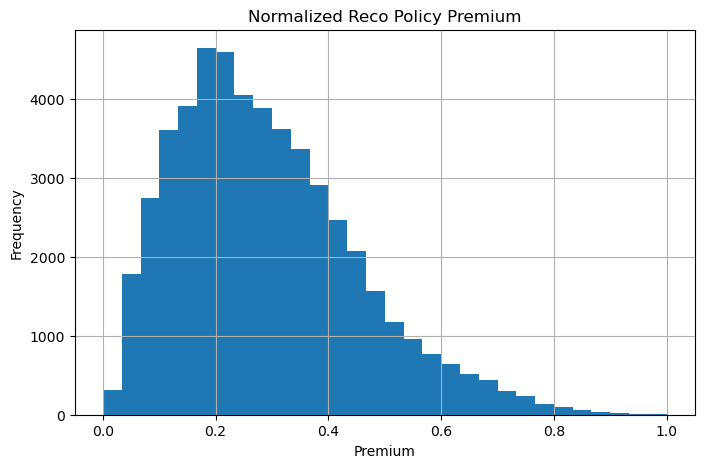


LABEL ENCODING
   ID  City_Code  Region_Code  Accomodation_Type  Reco_Insurance_Type  \
0   1         22         3213                  1                    0   
1   2         31         1117                  0                    1   
2   3         31         3732                  0                    0   
3   4         16         4378                  0                    1   
4   5         34         2190                  1                    0   

   Upper_Age  Lower_Age  Is_Spouse  Health Indicator  Holding_Policy_Duration  \
0   0.315789   0.338983          0                 0                        5   
1   1.000000   0.101695          0                 1                        0   
2   0.245614   0.271186          0                 0                        0   
3   0.596491   0.542373          0                 0                        5   
4   0.456140   0.474576          0                 1                        8   

   Holding_Policy_Type  Reco_Policy_Cat  Reco_Policy_Premi

In [2]:
# ============================================================
# EXPERIMENT 3
# EXPLORATORY DATA ANALYSIS (EDA)
# DATA CLEANING AND DATA TRANSFORMATION
# Dataset: Health Insurance Lead Prediction Raw Data.csv
# ============================================================

# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Health Insurance Lead Prediction Raw Data.csv")

print("="*80)
print("FIRST 5 ROWS")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("LAST 5 ROWS")
print("="*80)
print(df.tail())

print("\nDataset Shape :", df.shape)

# ============================================================
# PROGRAM 1
# IDENTIFY MISSING VALUES
# ============================================================

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)

print(df.isnull())

# ============================================================
# PROGRAM 2
# COUNT MISSING VALUES
# ============================================================

print("\n" + "="*80)
print("COUNT OF MISSING VALUES")
print("="*80)

print(df.isnull().sum())

# ============================================================
# PROGRAM 3
# REPLACE MISSING VALUES
# ============================================================

print("\n" + "="*80)
print("REPLACING MISSING VALUES")
print("="*80)

# Numerical Columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Categorical Columns
categorical_cols = df.select_dtypes(include="object").columns

# Fill Numerical Missing Values with Mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill Categorical Missing Values with Mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Filling\n")
print(df.isnull().sum())

# ============================================================
# PROGRAM 4
# REMOVE DUPLICATE RECORDS
# ============================================================

print("\n" + "="*80)
print("DUPLICATE RECORDS")
print("="*80)

duplicates = df.duplicated().sum()

print("Duplicate Rows Before Removal :", duplicates)

df.drop_duplicates(inplace=True)

print("Duplicate Rows After Removal :", df.duplicated().sum())

print("Dataset Shape :", df.shape)

# ============================================================
# PROGRAM 5
# DETECT OUTLIERS
# ============================================================

print("\n" + "="*80)
print("OUTLIER DETECTION")
print("="*80)

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outliers)} Outliers")

# -----------------------------
# Box Plot
# -----------------------------

plt.figure(figsize=(8,5))
plt.boxplot(df["Reco_Policy_Premium"])
plt.title("Box Plot of Reco Policy Premium")
plt.ylabel("Premium")
plt.grid(True)
plt.show()

# ============================================================
# PROGRAM 6
# NORMALIZATION
# ============================================================

print("\n" + "="*80)
print("MIN-MAX NORMALIZATION")
print("="*80)

scaler = MinMaxScaler()

columns_to_normalize = [
    "Upper_Age",
    "Lower_Age",
    "Holding_Policy_Type",
    "Reco_Policy_Premium"
]

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print(df[columns_to_normalize].head())

# Histogram

plt.figure(figsize=(8,5))
plt.hist(df["Reco_Policy_Premium"], bins=30)
plt.title("Normalized Reco Policy Premium")
plt.xlabel("Premium")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# ============================================================
# PROGRAM 7
# LABEL ENCODING
# ============================================================

print("\n" + "="*80)
print("LABEL ENCODING")
print("="*80)

label_columns = df.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in label_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

# ============================================================
# PROGRAM 8
# ONE HOT ENCODING
# ============================================================

print("\n" + "="*80)
print("ONE HOT ENCODING")
print("="*80)

df_onehot = pd.get_dummies(
    df,
    columns=label_columns,
    dtype=int
)

print(df_onehot.head())

# ============================================================
# FINAL DATASET
# ============================================================

print("\n" + "="*80)
print("FINAL CLEANED DATASET")
print("="*80)

print(df.head())

# ============================================================
# DATASET INFORMATION
# ============================================================

print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)

print(df.info())

# ============================================================
# STATISTICAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

print(df.describe())

# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv("Health_Insurance_Cleaned.csv", index=False)

print("\nCleaned dataset saved successfully as 'Health_Insurance_Cleaned.csv'")